# Análisis de usuarios de Instagram

**Integrantes:**

Andrea Valentina Delgado Ruiz

Daniel Felipe Calderón Calderón

# Introducción del dataset

Instagram es una red social dedicada al intercambio de contenido visual, especialmente fotografías y videos. A través de funciones como likes, comentarios, mensajes directos, historias y reels, los usuarios pueden
comunicarse, interactuar, compartir momentos y consumir contenido de manera rápida y continua. Con el paso del tiempo, esta plataforma ha ganado gran popularidad a nivel mundial y ha incrementado significativamente su uso, consolidándose no solo como un medio de comunicación y entretenimiento, sino también como una herramienta clave para el marketing y la promoción digital, influyendo en los hábitos de las personas y en la manera en que estas se relacionan.

Este proyecto tiene como propósito analizar un conjunto de datos compuesto por 1.547.896 registros correspondientes a usuarios de Instagram creados sintéticamente, organizados en 25 variables. A partir de esta información, se busca estudiar el comportamiento de los datos mediante el uso de técnicas estadísticas descriptivas y la elaboración de diversas representaciones gráficas que permitan identificar patrones, relaciones y tendencias.
El conjunto de datos integra variables cuantitativas, cualitativas y temporales, lo que permite realizar un análisis del estilo de vida y las condiciones sociodemográficas de los usuarios. Entre los aspectos evaluados se incluyen indicadores de salud y bienestar, tales como niveles de estrés, horas de ejercicio, cantidad de pasos diarios, índice de masa corporal, calidad del sueño, presión arterial y nivel de felicidad. Estos factores se analizan en relación con el uso de la aplicación, específicamente el tiempo de permanencia y la cantidad de reels consumidos por día.

Asimismo, incorpora variables demográficas y socioeconómicas como país de residencia, zona de vivienda (urbana o rural), nivel educativo, nivel de ingresos y situación laboral. El objetivo es explorar de qué manera el uso de redes sociales puede relacionarse con la productividad, los hábitos saludables y el bienestar general de los usuarios.

Finalmente, se incluye una variable temporal correspondiente a la fecha del último inicio de sesión, la cual permite analizar patrones de uso a lo largo del tiempo.

Dataset extraído de [Kaggle](https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis/data) publicado en Enero de 2026.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Clasificación de las variables**

## Cuantitativas
**Discretas:**

*   age: Edad del usuario expresada en años cumplidos.
*   blood_pressure_systolic: Valor de la presión arterial sistólica (mmHg), que corresponde a la presión ejercida sobre las arterias cuando el corazón se contrae y bombea sangre.
*   daily_steps_count: Número total de pasos que el usuario realiza en un día.
*   books_read_per_year: Cantidad de libros leídos por el usuario en un año.
*   reels_watched_per_day: Número de reels visualizados por el usuario diariamente.
*   time_on_explore_per_day: Tiempo total, en minutos, que el usuario dedica diariamente a la sección "Explorar".
*   time_on_messages_per_day: Tiempo total, en minutos, que el usuario emplea al día en la sección de mensajes directos.
*   time_on_reels_per_day: Tiempo total, en minutos, que el usuario pasa viendo reels cada día.

**Continuas:**

*   exercise_hours_per_week: Número de horas de actividad física realizadas por el usuario en una semana.
*   sleep_hours_per_night: Cantidad promedio de horas de sueño por noche.
*   body_mass_index: Índice de masa corporal (IMC), indicador que relaciona el peso y la estatura de la persona para evaluar su estado nutricional.
*   weekly_work_hours: Número total de horas trabajadas por semana.
*   daily_active_minutes_instagram: Cantidad de minutos activos que el usuario permanece en Instagram durante un día.


## Cualitativas
**Nominales:**

*   gender: Género del usuario (por ejemplo, masculino o femenino).
*   country: País de residencia del usuario.
*   urban_rural: Tipo de zona de residencia (urbana o rural).
*   employment_status: Situación laboral del usuario (por ejemplo, empleado, desempleado, independiente, estudiante, etc.).
*   smoking: Indica si el usuario fuma o no.
*   alcohol_frequency: Frecuencia con la que el usuario consume bebidas alcohólicas.

**Ordinales:**

*   income_level: Nivel de ingresos del usuario, clasificado en categorías ordenadas.
*   education_level: Nivel educativo alcanzado, organizado jerárquicamente.
*   diet_quality: Evaluación cualitativa de la calidad de la dieta del usuario (por ejemplo, baja, media, alta).
*   perceived_stress_score: Nivel de estrés percibido por el usuario, posiblemente relacionado con su estilo de vida y uso de la plataforma.
*   self_reported_happiness: Nivel de felicidad reportado por el usuario según su percepción personal.

**Temporales:**

*   last_login_date: Fecha del último inicio de sesión del usuario en Instagram, utilizada para analizar patrones de actividad a lo largo del tiempo.

## Visualización del dataset original

In [34]:
df = pd.read_csv('/content/drive/MyDrive/Estadistica/instagram_usage_lifestyle.csv')
df.describe()

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,7.739485e+05,3.898544e+01,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,...,3.762037e+01,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,5.002404e-01,2.017501e+03,2.050971e+01,1.975254e+00,1.644642e+00
std,4.468392e+05,1.529453e+01,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,...,2.535788e+01,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,2.887827e-01,4.611735e+00,8.697454e+00,1.352058e+00,1.812684e+00
min,1.000000e+00,1.300000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,2.000000e+01,0.000000e+00,2.010000e+03,5.000000e+00,0.000000e+00,6.700000e-01
25%,3.869748e+05,2.600000e+01,4.000000e+00,6.300000e+00,1.000000e+01,3.000000e+00,2.230000e+01,1.070000e+02,7.000000e+01,7.940000e+03,...,1.800000e+01,1.600000e+01,2.900000e+01,5.430000e+02,6.630000e+02,2.500000e-01,2.013000e+03,1.330000e+01,1.000000e+00,1.000000e+00
50%,7.739485e+05,3.900000e+01,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,2.500000e+01,1.240000e+02,7.900000e+01,8.000000e+03,...,3.400000e+01,3.100000e+01,5.400000e+01,1.154000e+03,1.519000e+03,5.000000e-01,2.017000e+03,2.040000e+01,2.000000e+00,1.100000e+00
75%,1.160922e+06,5.200000e+01,9.700000e+00,7.700000e+00,3.000000e+01,8.000000e+00,2.770000e+01,1.420000e+02,9.000000e+01,8.060000e+03,...,5.300000e+01,4.700000e+01,8.000000e+01,2.459000e+03,3.451000e+03,7.500000e-01,2.022000e+03,2.760000e+01,3.000000e+00,1.290000e+00
max,1.547896e+06,6.500000e+01,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,4.500000e+01,1.590000e+02,9.900000e+01,8.473000e+03,...,1.710000e+02,1.380000e+02,2.220000e+02,2.088110e+05,1.000000e+04,1.000000e+00,2.025000e+03,5.200000e+01,5.000000e+00,1.867000e+01


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [36]:
set_column = set(df['daily_steps_count'].tolist())
print(set_column)

{8192, 8193, 8194, 8195, 8196, 8197, 8198, 8199, 8200, 8201, 8202, 8203, 8204, 8205, 8206, 8207, 8208, 8209, 8210, 8211, 8212, 8213, 8214, 8215, 8216, 8217, 8218, 8219, 8220, 8221, 8222, 8223, 8224, 8225, 8226, 8227, 8228, 8229, 8230, 8231, 8232, 8233, 8234, 8235, 8236, 8237, 8238, 8239, 8240, 8241, 8242, 8243, 8244, 8245, 8246, 8247, 8248, 8249, 8250, 8251, 8252, 8253, 8254, 8255, 8256, 8257, 8258, 8259, 8260, 8261, 8262, 8263, 8264, 8265, 8266, 8267, 8268, 8269, 8270, 8271, 8272, 8273, 8274, 8275, 8276, 8277, 8278, 8279, 8280, 8281, 8282, 8283, 8284, 8285, 8286, 8287, 8288, 8289, 8290, 8291, 8292, 8293, 8294, 8295, 8296, 8297, 8298, 8299, 8300, 8301, 8302, 8303, 8304, 8305, 8306, 8307, 8308, 8309, 8310, 8311, 8312, 8313, 8314, 8315, 8316, 8317, 8318, 8319, 8320, 8321, 8322, 8323, 8324, 8325, 8326, 8327, 8328, 8329, 8330, 8331, 8332, 8333, 8334, 8335, 8336, 8337, 8338, 8339, 8340, 8341, 8342, 8343, 8344, 8345, 8346, 8347, 8348, 8349, 8350, 8351, 8352, 8353, 8354, 8355, 8356, 8357, 835

In [37]:
df.isnull().sum()

,0
user_id,0
app_name,0
age,0
gender,0
country,0
urban_rural,0
income_level,0
employment_status,0
education_level,0
relationship_status,0


In [38]:
df.shape

(1547896, 58)

In [39]:
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


<Axes: >

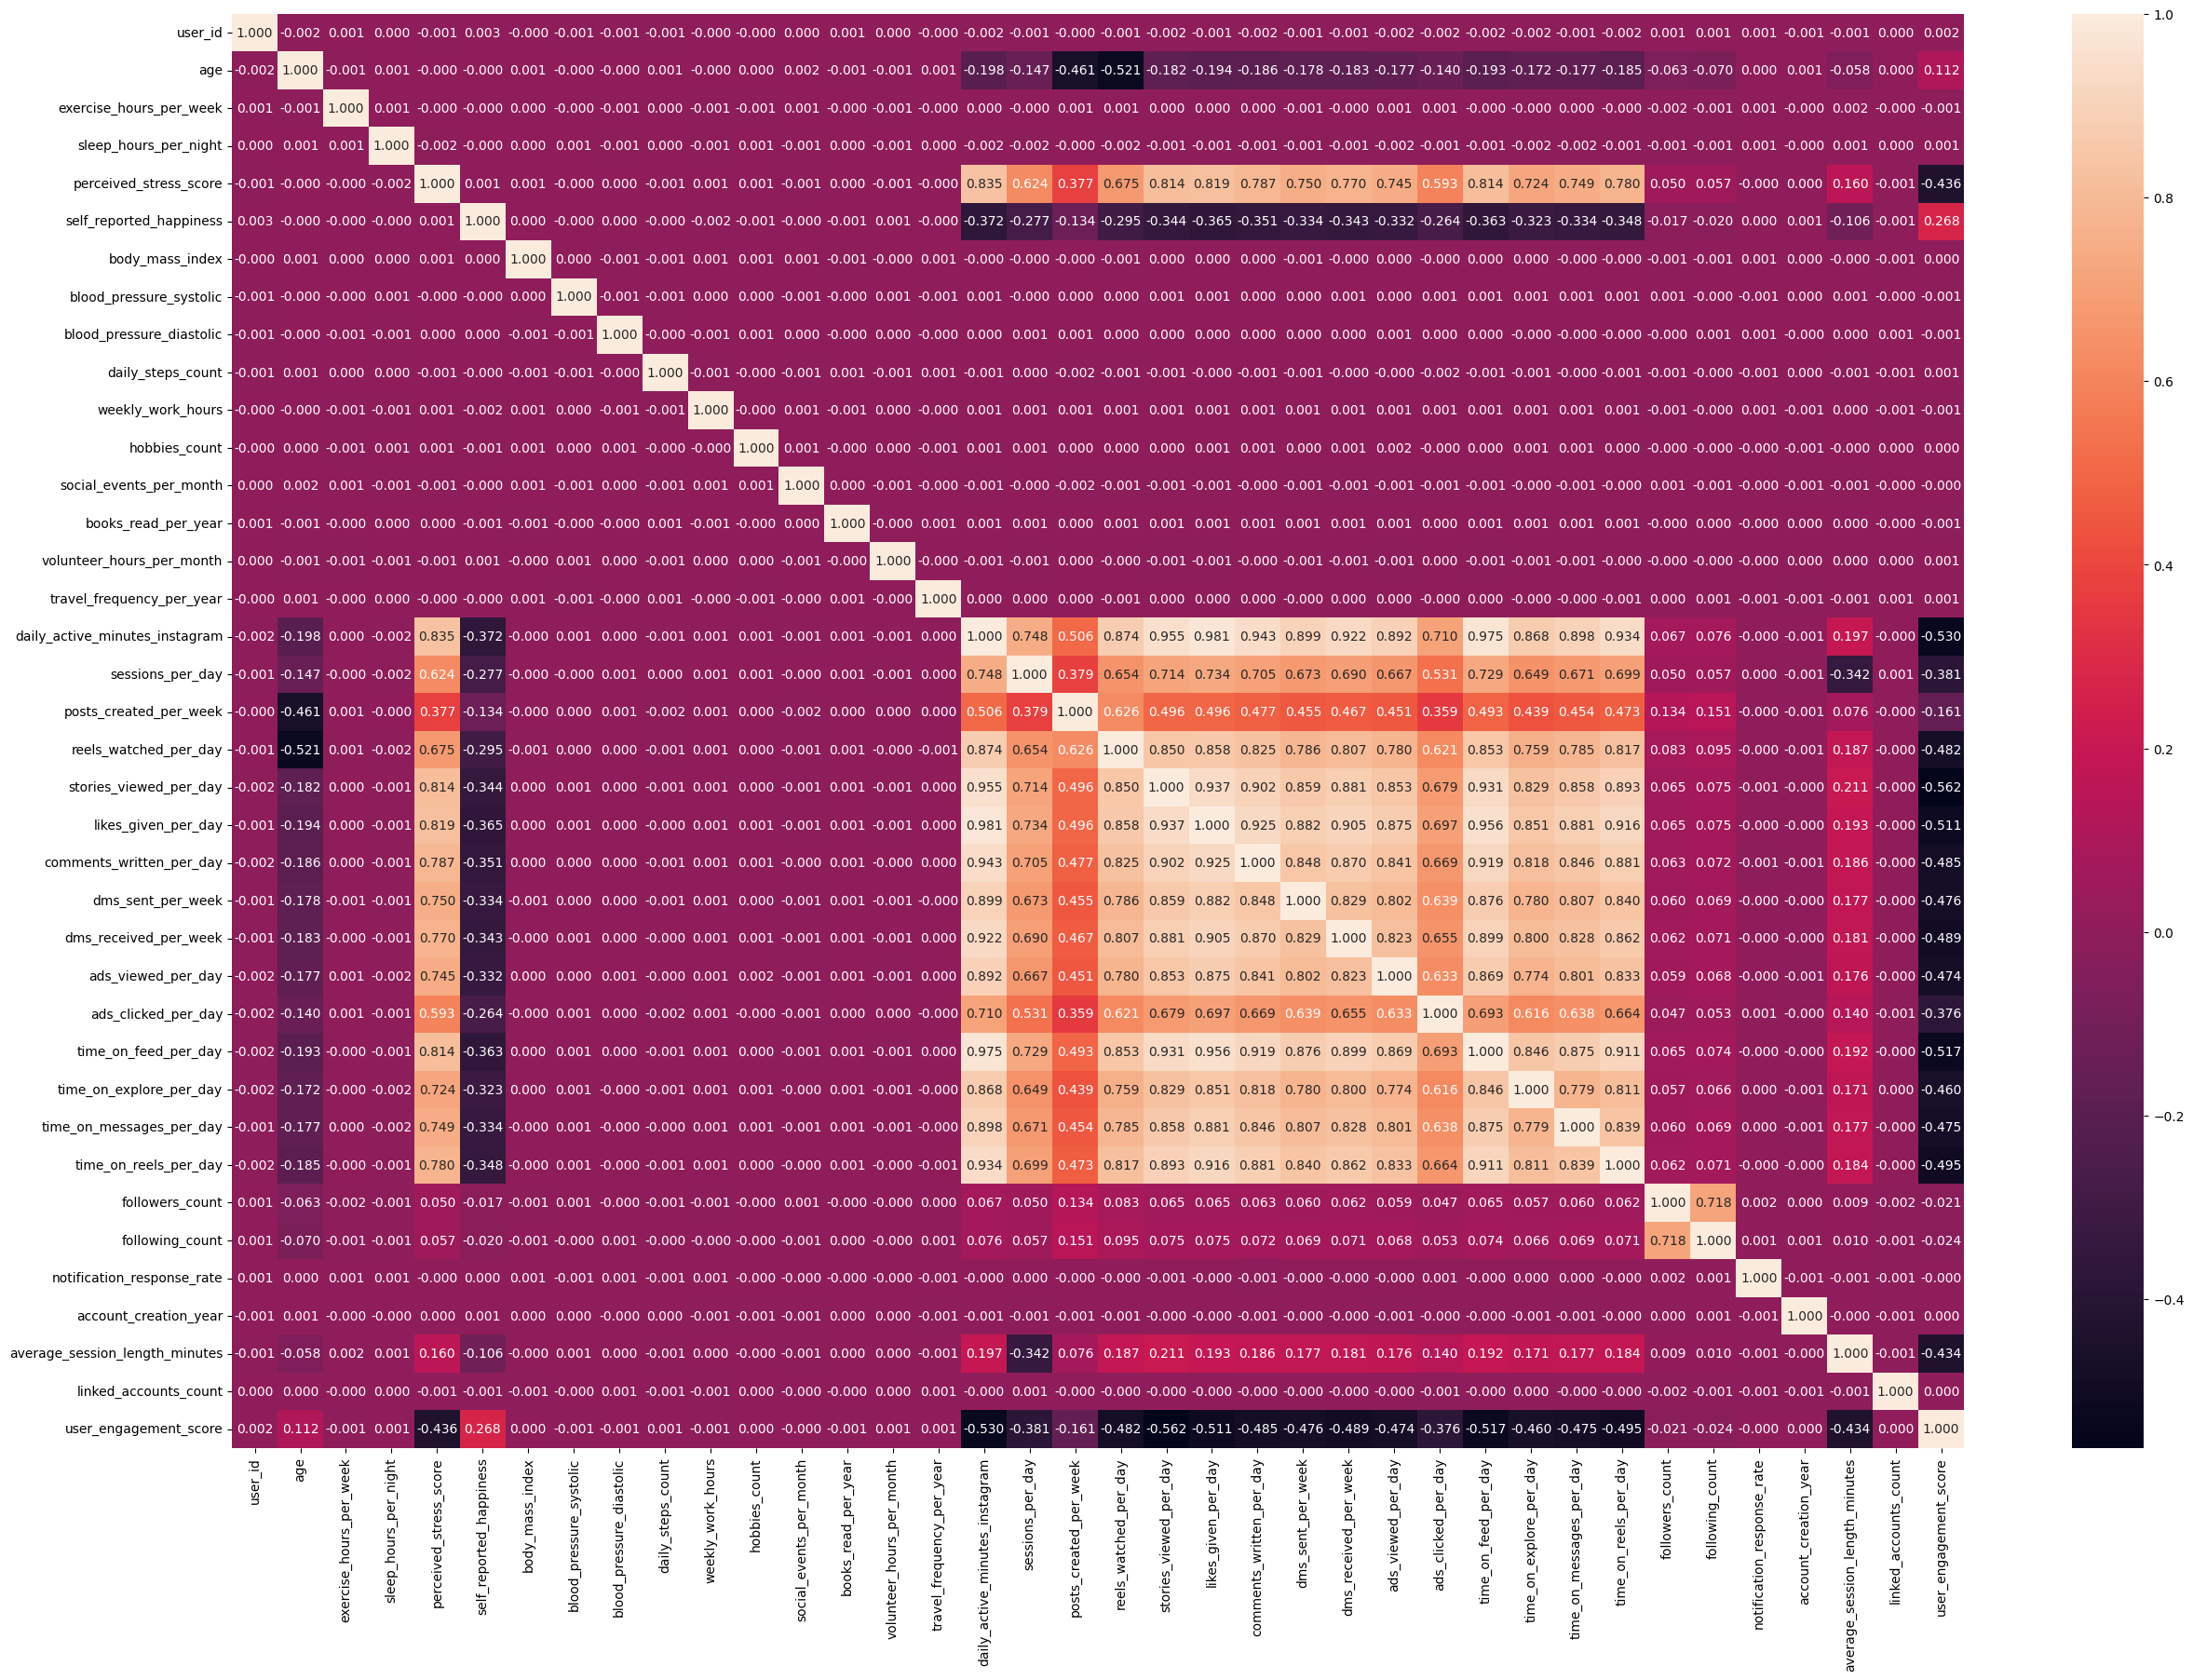

In [40]:
df_num = df.select_dtypes(include="number") # un sub-dataset con solo las columnas con datos numéricos
plt.subplots(figsize=(30,20))
corr = df_num.corr()
sns.heatmap(corr, annot=True, fmt=".3f")

## Dataset de estudio: df_clean
Limpiamos el dataset, dejando solo las columnas que vamos a utilizar

In [41]:
df_clean = df.drop(["user_id","blood_pressure_diastolic","app_name","relationship_status", "has_children", "hobbies_count", "social_events_per_month", "volunteer_hours_per_month", "travel_frequency_per_year", "sessions_per_day",
                    "posts_created_per_week", "stories_viewed_per_day", "likes_given_per_day", "comments_written_per_day", "dms_sent_per_week",
                    "dms_received_per_week", "ads_viewed_per_day", "ads_clicked_per_day", "time_on_feed_per_day", "followers_count", "following_count", "uses_premium_features", "notification_response_rate",
                    "account_creation_year", "average_session_length_minutes", "content_type_preference", "preferred_content_theme", "privacy_setting_level",
                    "two_factor_auth_enabled", "biometric_login_used", "linked_accounts_count", "subscription_status", "user_engagement_score"], axis=1, errors='ignore')

In [42]:
df_clean.shape

(1547896, 25)

In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 25 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   age                             1547896 non-null  int64  
 1   gender                          1547896 non-null  object 
 2   country                         1547896 non-null  object 
 3   urban_rural                     1547896 non-null  object 
 4   income_level                    1547896 non-null  object 
 5   employment_status               1547896 non-null  object 
 6   education_level                 1547896 non-null  object 
 7   exercise_hours_per_week         1547896 non-null  float64
 8   sleep_hours_per_night           1547896 non-null  float64
 9   diet_quality                    1547896 non-null  object 
 10  smoking                         1547896 non-null  object 
 11  alcohol_frequency               1547896 non-null  object 
 12  

In [44]:
df_clean.head()

,age,gender,country,urban_rural,income_level,employment_status,education_level,exercise_hours_per_week,sleep_hours_per_night,diet_quality,...,blood_pressure_systolic,daily_steps_count,weekly_work_hours,books_read_per_year,daily_active_minutes_instagram,reels_watched_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,last_login_date
0,51,Female,India,Rural,High,Retired,Bachelor’s,7.2,7.7,Good,...,148,8107,49.9,7,5.0,42,1,1,2,2025-11-02
1,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,10.9,8.6,Very poor,...,133,8059,15.6,10,74.0,78,19,16,19,2025-03-22
2,41,Female,Canada,Urban,Middle,Student,Bachelor’s,5.0,6.7,Good,...,135,7872,31.8,14,5.0,29,1,1,1,2025-08-10
3,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,10.6,6.5,Poor,...,105,7801,43.4,13,233.0,241,64,52,64,2025-03-31
4,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,7.7,6.8,Average,...,146,8005,50.2,12,184.0,146,55,22,55,2025-03-19


<Axes: >

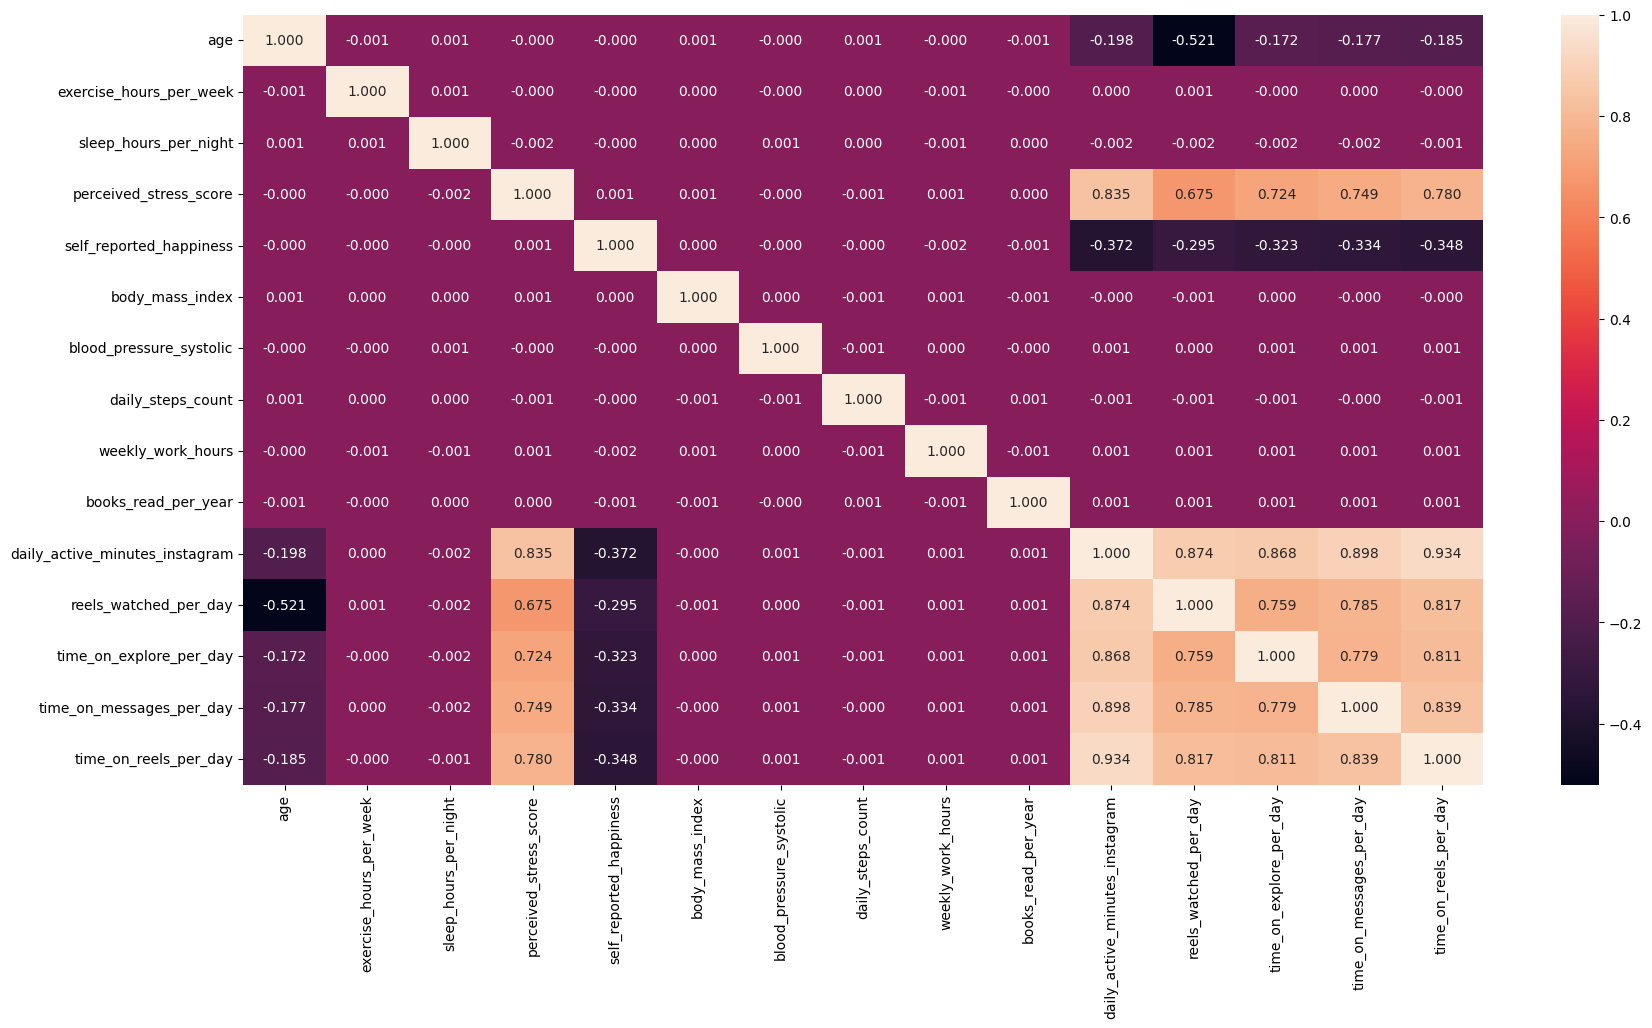

In [45]:
# Matriz de corelación, heat map
df_clean_num = df_clean.select_dtypes(include="number") # un sub-dataset con solo las columnas con datos numéricos
plt.subplots(figsize=(20,10))
corr = df_clean_num.corr()
sns.heatmap(corr, annot=True, fmt=".3f")

In [46]:
set_column = set(df_clean["last_login_date"].to_list())
print(set_column)

{'2025-12-25', '2025-03-09', '2025-05-08', '2025-08-05', '2025-10-20', '2025-09-20', '2025-03-12', '2025-05-07', '2025-02-24', '2025-11-07', '2025-04-29', '2025-06-11', '2025-03-30', '2025-04-05', '2025-09-07', '2025-10-10', '2025-01-05', '2025-11-09', '2025-10-06', '2025-12-09', '2025-03-10', '2025-09-15', '2025-08-03', '2025-03-17', '2025-05-14', '2025-08-13', '2025-03-03', '2025-04-06', '2025-01-30', '2025-05-25', '2025-01-09', '2025-07-02', '2025-08-18', '2025-07-26', '2025-02-03', '2025-04-09', '2025-06-25', '2025-07-21', '2025-12-28', '2025-10-09', '2025-01-15', '2025-10-23', '2025-02-05', '2025-08-10', '2025-12-12', '2025-06-14', '2025-08-01', '2025-03-04', '2025-12-05', '2025-05-30', '2025-06-08', '2025-10-18', '2025-01-29', '2025-05-29', '2025-08-07', '2025-05-01', '2025-11-10', '2025-07-28', '2025-12-30', '2025-01-07', '2025-09-23', '2025-02-09', '2025-03-08', '2025-12-18', '2025-09-06', '2025-04-22', '2025-08-14', '2025-01-13', '2025-07-12', '2025-10-17', '2025-05-18', '2025

##Gráficas


###**Gráfica de tiempo**

Esta gráfica de tiempo tiene como objetivo analizar el comportamiento del uso de la aplicación "Instagram" durante el año 2025 y enero de 2026, haciendo uso de la variable last_login_date, la cual registra la fecha del último inicio de sesión de cada usuario. A través de esta visualización se busca identificar si el uso de la app ha aumentado, disminuido o se ha mantenido estable a lo largo de este período de tiempo.

<Axes: title={'center': 'Uso de Instagram a lo largo del tiempo'}, xlabel='Fecha', ylabel='Número de usuarios'>

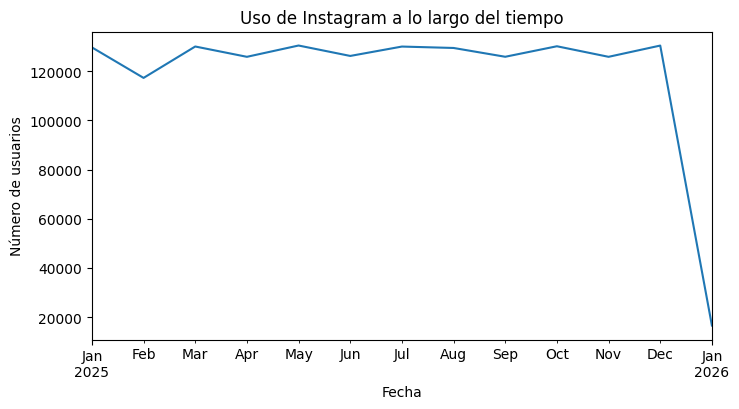

In [47]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_clean['last_login_date'] = pd.to_datetime(df_clean['last_login_date'])

df_clean.groupby(df_clean['last_login_date'].dt.to_period('M')).size().plot(
    figsize=(8, 4),
    title='Uso de Instagram a lo largo del tiempo',
    xlabel='Fecha',
    ylabel='Número de usuarios'
)





A lo largo de 2025 la gráfica evidencia un comportamiento constante, con una cantidad de usuarios que oscila entre los 120.000 y 130.000 registros mensuales. Esta estabilidad se mantiene durante los doce meses del año, con una leve caída en febrero y pequeñas variaciones en algunos meses que no representan tendencias significativas.

Para enero de 2026 se observa una caída abrupta en el número de usuarios registrados, pasando de aproximadamente 130.000 en diciembre de 2025 a cerca de 18.000 en enero de 2026. Sin embargo, esta caída no refleja una disminución real en el uso de la aplicación, sino que se debe al corte temporal del dataset: dado que fue publicado en enero de 2026, el registro de usuarios es parcial y no abarca el mes completo, lo que explica este descenso pronunciado al final de la gráfica.

###**Gráfica de caja**

Con esta gráfica de caja se busca analizar la relación entre el nivel de estrés percibido (perceived_stress_score) y los minutos diarios activos en Instagram (daily_active_minutes_instagram). Cada caja representa un nivel de estrés del 0 al 40, permitiendo observar cómo varía el tiempo de uso de la aplicación a medida que aumenta el estrés del usuario.

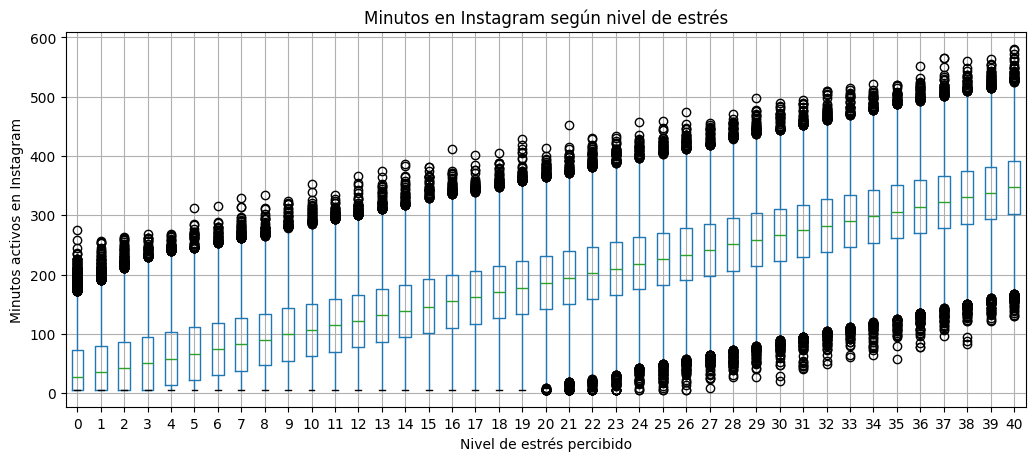

In [48]:
# @title
df_clean.boxplot(
    column='daily_active_minutes_instagram',
    by='perceived_stress_score',
    figsize=(12, 5)
)

plt.title('Minutos en Instagram según nivel de estrés')
plt.suptitle('')
plt.xlabel('Nivel de estrés percibido')
plt.ylabel('Minutos activos en Instagram');

En la gráfica se evidencia una relación entre ambas variables: a mayor nivel de estrés, mayor tiempo de uso de Instagram. La mediana sube progresivamente desde aproximadamente 30 minutos en el nivel 0 hasta cerca de 330 minutos en el nivel 40, lo que indica que los usuarios más estresados tienden a pasar significativamente más tiempo en la aplicación.

Esto se puede interpretar como: el uso de Instagram como mecanismo de escape o distracción ante el estrés.

### **Histograma de minutos activos diarios en Instagram**

#### Objeto de estudio

Este histograma tiene como objetivo principal visualizar la distribución de la cantidad de minutos que los usuarios permanecen activos en Instagram al día. Esto nos permitirá comprender si el uso de la aplicación tiende a ser bajo, moderado o alto entre la población de usuarios, y si hay concentraciones en ciertos rangos de tiempo.

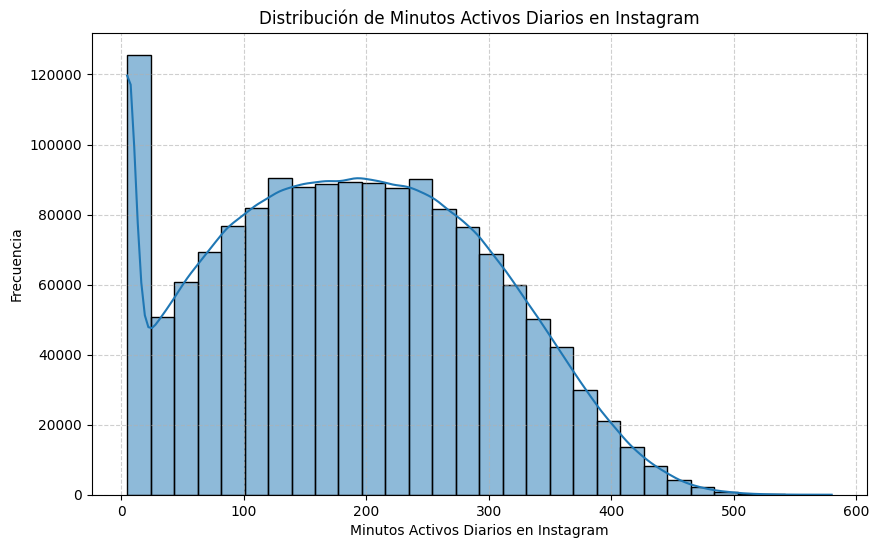

In [49]:
# @title
plt.figure(figsize=(10, 6))
sns.histplot(df_clean_num['daily_active_minutes_instagram'], bins=30, kde=True)
plt.title('Distribución de Minutos Activos Diarios en Instagram')
plt.xlabel('Minutos Activos Diarios en Instagram')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Lectura del resultado

La forma del histograma nos indicará patrones de uso. Si la mayoría de las barras se concentran en el lado izquierdo, sugiere que la mayoría de los usuarios pasan poco tiempo en la aplicación. Una distribución más simétrica indicaría un uso más variado, mientras que picos en diferentes lugares podrían señalar distintos segmentos de usuarios con hábitos de uso específicos. La línea KDE (Estimación de Densidad de Kernel) suavizará la distribución para facilitar la identificación de la tendencia general.

### **Gráfico de Barras: Promedio de Engagement en Instagram**

#### Objeto de estudio

Este gráfico de barras tiene como objetivo comparar el nivel promedio de engagement de los usuarios en tres actividades clave de Instagram: la cantidad de reels vistos por día (`reels_watched_per_day`), el tiempo dedicado a la sección de mensajes por día (`time_on_messages_per_day`) y el tiempo de exploración diario (`time_on_explore_per_day`). Al visualizar los promedios de estas métricas, podemos identificar rápidamente cuáles son las actividades más o menos consumidas por los usuarios en general. Se debe tener en cuenta que las unidades de medida son diferentes (número de reels vs. minutos), lo cual se indicará en el gráfico.

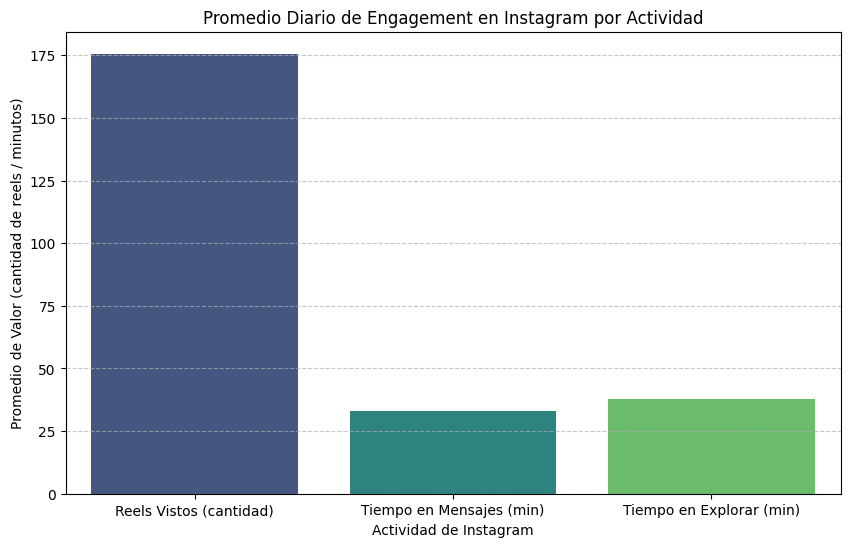

In [50]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el promedio de las columnas de interés
engagement_means = df_clean[['reels_watched_per_day', 'time_on_messages_per_day', 'time_on_explore_per_day']].mean()

# Crear un DataFrame para facilitar la visualización
engagement_df = pd.DataFrame({
    'Actividad': ['Reels Vistos (cantidad)', 'Tiempo en Mensajes (min)', 'Tiempo en Explorar (min)'],
    'Promedio': engagement_means.values
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Actividad', y='Promedio', hue='Actividad', data=engagement_df, palette='viridis', legend=False)
plt.title('Promedio Diario de Engagement en Instagram por Actividad')
plt.ylabel('Promedio de Valor (cantidad de reels / minutos)')
plt.xlabel('Actividad de Instagram')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Lectura del resultado

El gráfico de barras mostrará el promedio de reels vistos por día y el promedio de minutos dedicados a mensajes y exploración. La altura de cada barra indicará la magnitud promedio de la interacción del usuario con esa actividad específica. Esto nos permitirá inferir qué tipo de contenido o interacción es más predominante en el uso diario de Instagram por parte de los usuarios. Por ejemplo, una barra alta para 'Reels Vistos' podría sugerir una alta preferencia por este formato, mientras que una barra alta para 'Tiempo en Mensajes' indicaría una fuerte inclinación a la comunicación directa.

### **Gráfico de Dispersión: Minutos Activos Diarios en Instagram vs. Felicidad Reportada**

#### Objeto de estudio

Este gráfico de dispersión tiene como objetivo analizar la posible correlación entre el tiempo que los usuarios pasan diariamente activos en Instagram (`daily_active_minutes_instagram`) y su nivel de felicidad auto-reportado (`self_reported_happiness`). Cada punto en el gráfico representará a un usuario, y su posición indicará estas dos métricas. La visualización busca identificar si hay patrones que sugieran una relación (positiva, negativa o nula) entre el uso de la aplicación y el bienestar emocional de los usuarios.

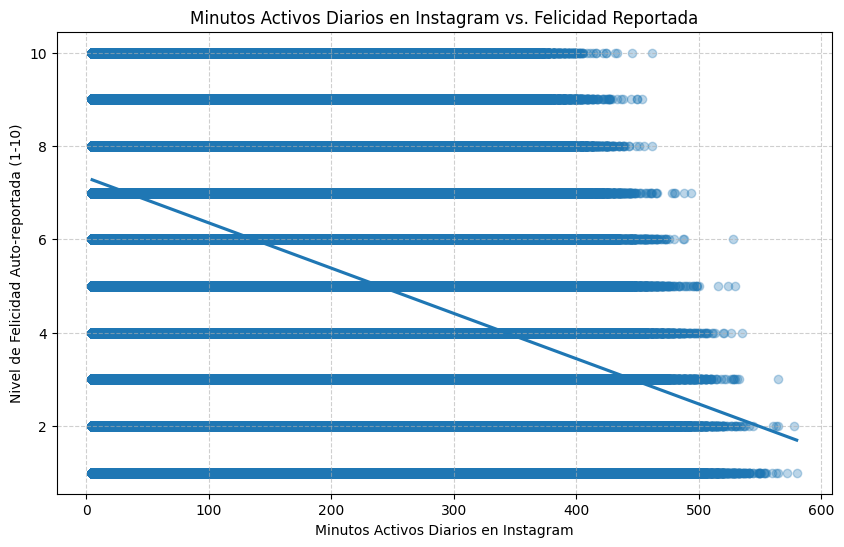

In [52]:
plt.figure(figsize=(10, 6))
sns.regplot(x='daily_active_minutes_instagram', y='self_reported_happiness', data=df_clean, scatter_kws={'alpha':0.3})
plt.title('Minutos Activos Diarios en Instagram vs. Felicidad Reportada')
plt.xlabel('Minutos Activos Diarios en Instagram')
plt.ylabel('Nivel de Felicidad Auto-reportada (1-10)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Lectura del resultado

Al observar el gráfico de dispersión, buscaremos patrones en la distribución de los puntos. Si los puntos tienden a subir de izquierda a derecha, podría indicar que un mayor tiempo en Instagram se asocia con un mayor nivel de felicidad (correlación positiva). Si los puntos tienden a bajar, podría sugerir lo contrario (correlación negativa). Si los puntos están distribuidos de forma aleatoria, sin un patrón claro, esto indicaría una correlación débil o inexistente entre estas dos variables. La densidad de los puntos también puede mostrar si hay concentraciones de usuarios con hábitos y niveles de felicidad similares. Es importante recordar que la correlación no implica causalidad.

### **Gráfico de Dispersión: Horas de Trabajo Semanales vs. Minutos Activos Diarios en Instagram**

#### Objeto de estudio

Este gráfico de dispersión tiene como objetivo analizar la posible correlación entre las horas que los usuarios trabajan semanalmente (`weekly_work_hours`) y el tiempo que pasan diariamente activos en Instagram (`daily_active_minutes_instagram`). Cada punto en el gráfico representará a un usuario, y su posición indicará estas dos métricas. La visualización busca identificar si hay patrones que sugieran una relación (positiva, negativa o nula) entre el tiempo dedicado al trabajo y el uso de la aplicación.

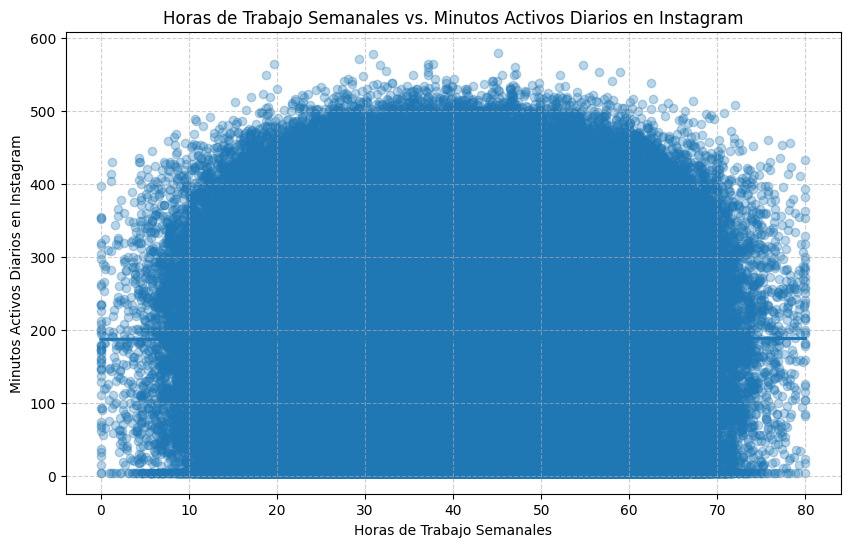

In [53]:
plt.figure(figsize=(10, 6))
sns.regplot(x='weekly_work_hours', y='daily_active_minutes_instagram', data=df_clean, scatter_kws={'alpha':0.3})
plt.title('Horas de Trabajo Semanales vs. Minutos Activos Diarios en Instagram')
plt.xlabel('Horas de Trabajo Semanales')
plt.ylabel('Minutos Activos Diarios en Instagram')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Lectura del resultado

Al observar el gráfico de dispersión, buscaremos patrones en la distribución de los puntos. Si los puntos tienden a agruparse de alguna manera (por ejemplo, formando una línea ascendente o descendente), esto podría sugerir una correlación entre las horas de trabajo y el uso de Instagram. Si los puntos están dispersos de forma aleatoria, sin un patrón claro, esto indicaría una correlación débil o inexistente. La densidad de los puntos también puede mostrar si hay concentraciones de usuarios con hábitos laborales y de uso de la aplicación similares. Es importante recordar que la correlación no implica causalidad.

### **Diagrama de árbol para predecir el nivel de ingresos**

#### Objeto de estudio

El diagrama de árbol de decisión tiene como objetivo identificar las características clave de los usuarios (como edad, nivel educativo, estado laboral, tiempo en Instagram y horas de trabajo) que influyen en su `income_level` (nivel de ingresos). Este análisis nos permitirá visualizar cómo una serie de decisiones basadas en estas características pueden llevar a clasificar a los usuarios en diferentes categorías de ingresos. Esto puede revelar patrones sobre el perfil socioeconómico y de uso de la aplicación de los usuarios, e incluso sugerir correlaciones entre el uso de Instagram y factores socioeconómicos.

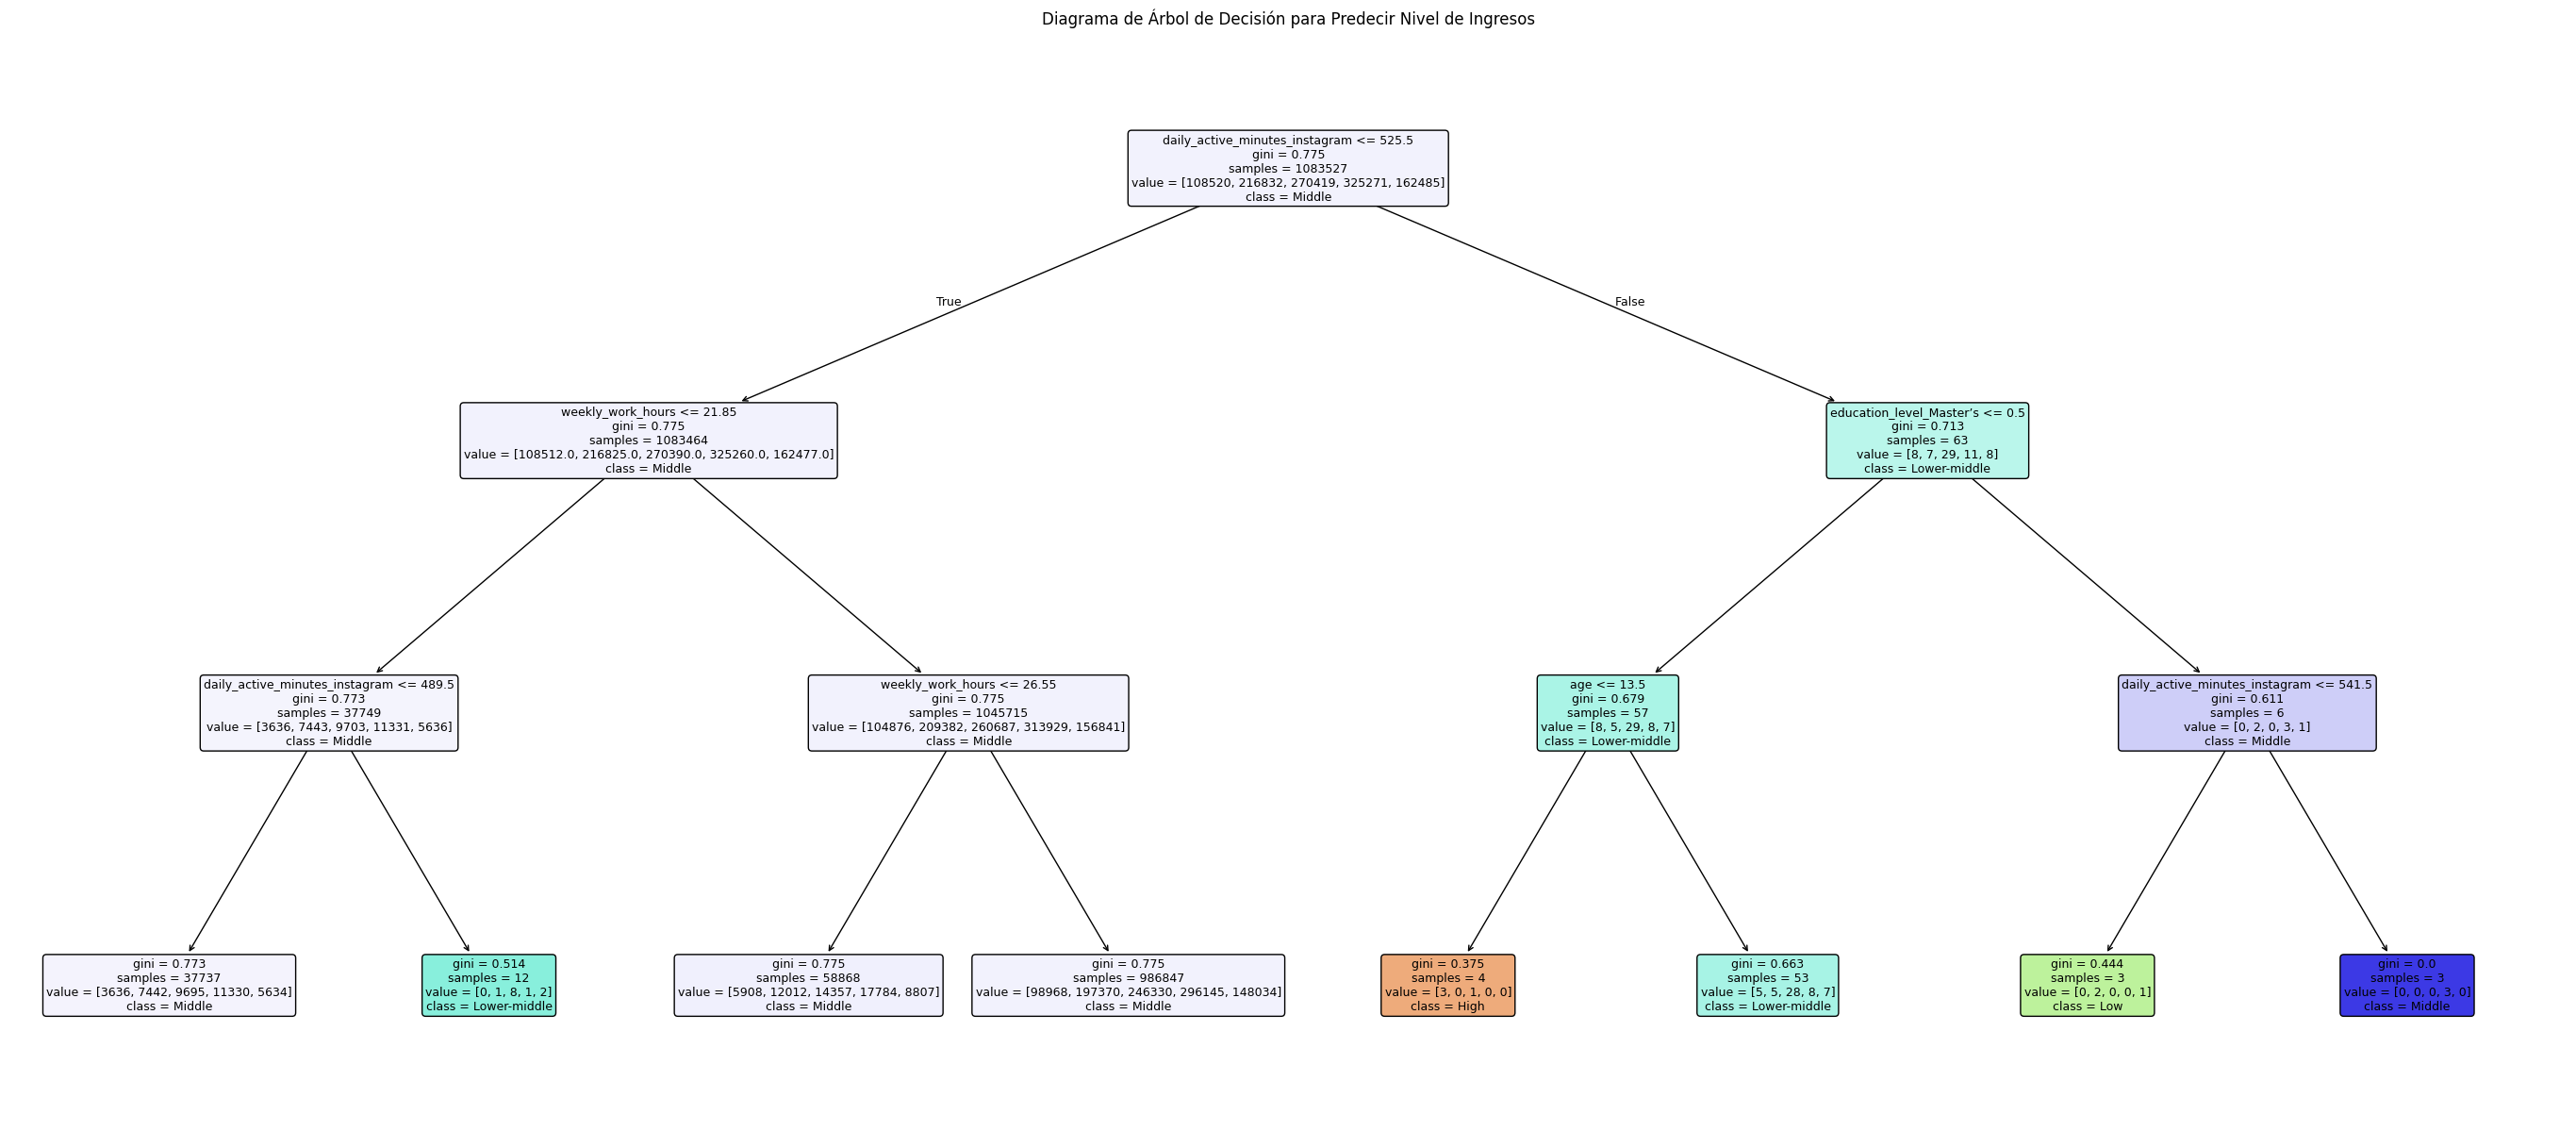

In [54]:
# @title
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Preparación de los datos
df_tree = df_clean.copy()

# Codificar la variable objetivo (income_level)
le = LabelEncoder()
df_tree['income_level_encoded'] = le.fit_transform(df_tree['income_level'])
y_labels = le.classes_

# Seleccionar características
features = ['age', 'education_level', 'employment_status', 'daily_active_minutes_instagram', 'weekly_work_hours']

X = df_tree[features]
y = df_tree['income_level_encoded']

# Codificación One-Hot para variables categóricas en X
X = pd.get_dummies(X, columns=['education_level', 'employment_status'], drop_first=True)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo de árbol de decisión
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42) # Limitar la profundidad para mejor visualización
dt_classifier.fit(X_train, y_train)

# Visualizar el árbol de decisión con un tamaño ajustado
plt.figure(figsize=(35, 15))  # Aumenta el tamaño de la figura
plot_tree(dt_classifier, feature_names=X.columns.tolist(), class_names=y_labels, filled=True, rounded=True, fontsize=9) # Reduce el tamaño de la fuente
plt.title('Diagrama de Árbol de Decisión para Predecir Nivel de Ingresos')
plt.show()

#### Lectura del resultado

El diagrama de árbol muestra una serie de nodos (divisiones) que representan decisiones basadas en las características de los usuarios. Cada nodo interno es una condición sobre una característica (por ejemplo, si la edad es menor o igual a X), y cada rama representa el resultado de esa condición. Las hojas del árbol son los nodos finales que predicen el `income_level`.

Al seguir un camino desde la raíz hasta una hoja, se puede ver la secuencia de decisiones que llevan a una clasificación de nivel de ingresos. Por ejemplo, se podría observar que los usuarios con un alto nivel educativo y cierto estado laboral tienden a tener un nivel de ingresos más alto. El árbol nos permite entender la importancia relativa de cada característica en la predicción del nivel de ingresos y cómo se combinan para formar reglas de clasificación. Las ramas más cercanas a la raíz del árbol indican las características más influyentes.